# Assignment 2

# Binary Classification of EV Battery Failure using Artificial Neural Networks (ANN)

Name: Arpita Shaielsh Anap 
Roll No: 05 
Class: A 


## Import the Libraires 

In [1]:
# Numerical computations
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warning messages
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

# Deep Learning
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


## Dataset Upload 

In [2]:

df = pd.read_csv("ev_battery_failure_dataset.csv")

# Display first five rows
df.head()

,vehicle_id,vehicle_brand,vehicle_model,vehicle_type,manufacturing_year,battery_manufacturer,battery_chemistry,battery_capacity_kwh,drive_type,odometer_km,...,sensor_fault_count,BMS_warning_count,abnormal_voltage_events,battery_stress_index,aging_score,thermal_health_score,charging_quality_score,driving_stress_score,predicted_remaining_life_cycles,battery_failure
0,EV100000,Nissan,Leaf,SUV,2019.0,CATL,LMO,82.54,RWD,98163.0,...,2.0,3.0,0.0,0.0,53.5,66.0,65.2,0.0,401.0,0
1,EV100001,Audi,e-tron,Sedan,2018.0,Samsung SDI,NaN,64.17,AWD,113600.0,...,0.0,3.0,0.0,51.0,38.8,67.8,46.3,40.9,1094.0,0
2,EV100002,Toyota,bZ4X,Van,2018.0,Guoxuan,NMC,90.92,RWD,242253.0,...,4.0,1.0,0.0,36.2,66.1,48.6,0.0,6.5,645.0,0
3,EV100003,Volkswagen,ID.3,Hatchback,2022.0,CATL,NMC,47.35,AWD,83700.0,...,0.0,3.0,1.0,23.4,32.5,58.2,NaN,NaN,867.0,0
4,EV100004,Tesla,Model X,Crossover,2015.0,BYD Battery,NMC,68.04,FWD,88784.0,...,3.0,2.0,1.0,51.2,45.4,51.0,NaN,100.0,1090.0,0


In [3]:

print("Shape of Dataset :", df.shape)

print("\nNumber of Rows :", df.shape[0])

print("Number of Columns :", df.shape[1])

Shape of Dataset : (200000, 70)

Number of Rows : 200000
Number of Columns : 70


### Exploring the Target Variable

In [4]:

df["battery_failure"].value_counts()

# Prize Distribution 
(df["battery_failure"].value_counts(normalize=True)*100).round(2)

battery_failure
0    90.04
1     9.96
Name: proportion, dtype: float64

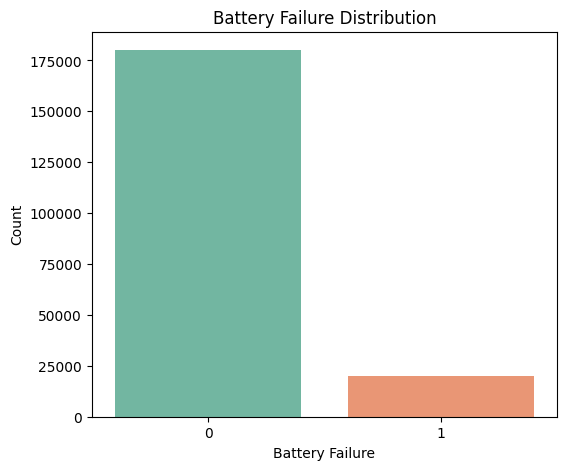

In [5]:
# ==========================================
# Visualizing Target Variable
# ==========================================

plt.figure(figsize=(6,5))

sns.countplot(
    x="battery_failure",
    data=df,
    palette="Set2"
)

plt.title("Battery Failure Distribution")

plt.xlabel("Battery Failure")

plt.ylabel("Count")

plt.show()

### Data Preprocessing

In [6]:
categorical_columns = df.select_dtypes(include=["object"]).columns

print(categorical_columns)

# number of the categorial coloumns 
print("Total Categorical Columns :", len(categorical_columns))

Index(['vehicle_id', 'vehicle_brand', 'vehicle_model', 'vehicle_type',
       'battery_manufacturer', 'battery_chemistry', 'drive_type',
       'fleet_or_private', 'battery_serial', 'terrain_type'],
      dtype='object')
Total Categorical Columns : 10


### Encoding Categorical Variables

In [7]:

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column].astype(str))

print("Categorical Features Encoded Successfully.")

Categorical Features Encoded Successfully.


### Feature Selection

In [8]:

X = df.drop("battery_failure", axis=1)

y = df["battery_failure"]

print("Feature Matrix Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Matrix Shape : (200000, 69)
Target Shape : (200000,)


### Train-Test Split

In [9]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape)

print("Testing Samples :", X_test.shape)

Training Samples : (160000, 69)
Testing Samples : (40000, 69)


In [10]:
# ==========================================
# Standard Scaling
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Scaling Completed.")

Feature Scaling Completed.


### Building the Artificial Neural Network (ANN)

In [11]:

model = Sequential()

# First Hidden Layer
model.add(Dense(
    units=128,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

# Second Hidden Layer
model.add(Dense(
    units=64,
    activation='relu'
))

# Third Hidden Layer
model.add(Dense(
    units=32,
    activation='relu'
))

# Output Layer
model.add(Dense(
    units=1,
    activation='sigmoid'
))

### Understanding the Activation Functions

In [12]:

# Compile ANN Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully.")

Model Compiled Successfully.


In [14]:
# ==========================================
# Train the ANN
# ==========================================

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)


Epoch 1/50
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9007 - loss: 0.3284 - val_accuracy: 0.8989 - val_loss: 0.3285
Epoch 2/50
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9008 - loss: 0.3238 - val_accuracy: 0.8989 - val_loss: 0.3277
Epoch 3/50
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9008 - loss: 0.3239 - val_accuracy: 0.8989 - val_loss: 0.3285
Epoch 4/50
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9008 - loss: 0.3238 - val_accuracy: 0.8989 - val_loss: 0.3275
Epoch 5/50
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.9008 - loss: 0.3239 - val_accuracy: 0.8989 - val_loss: 0.3281
Epoch 6/50
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9008 - loss: 0.3238 - val_accuracy: 0.8989 - val_loss: 0.3275
Epoch 7/50
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9008 - loss: 0.3239 - val_accuracy: 0.8989 - val_loss: 0.3275
Epoch 8/50
4000/4000 ━━━━━━━━━━━━━━━━━━━━ 44s 11ms/step - accuracy: 0.9008 - loss: 0.32

In [15]:
# Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", loss)

print("Test Accuracy :", accuracy)

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9004 - loss: 0.3243
Test Loss : 0.32426008582115173
Test Accuracy : 0.9003999829292297


In [ ]:

# Predict Test Data
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

print(y_pred[:10])

1250/1250 ━━━━━━━━━━━━━━━━━━━━ 1s 991us/step
[[0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]
 [0]]


In [17]:

# Calculate Classification Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print metrics
print("="*45)
print("Model Evaluation Metrics")
print("="*45)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Model Evaluation Metrics
Accuracy : 0.9004
Precision: 0.0000
Recall   : 0.0000
F1-Score : 0.0000


In [18]:
# ==========================================
# Classification Report
# ==========================================

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95     36016
           1       0.00      0.00      0.00      3984

    accuracy                           0.90     40000
   macro avg       0.45      0.50      0.47     40000
weighted avg       0.81      0.90      0.85     40000

